# Process Tree Discovery

Discover process trees from an event log using the inductive miner, visualize them, convert to BPMN, and analyze structural regions (subtrees) as candidates for subprocess extraction.

In [6]:
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from collections import Counter

## Load Event Log
Read a simple event log (AB_Example.xes) for process discovery.

In [ ]:
LOG_PATH = "../../data/villach/processflow_export.xes" 
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH) )

parsing log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

## Discover Process Tree
Use the inductive miner to discover a process tree from the event log.

In [ ]:
process_tree = pm4py.discover_process_tree_inductive(
    event_log
)

print(process_tree)

->( '1017', +( X( tau, '2200' ), X( ->( '1027', '2085', '2095' ), ->( '1028', '1029', '1033', '1035', X( tau, '2205', '2210' ) ) ) ), '2230', '2250', X( tau, '7777', ->( '2255', X( tau, '2295' ) ) ), '9020', '9030', '9050', X( tau, ->( '9390', '9450' ) ), '9841', '9922', '9924', '9996' )


## Save Process Tree as PTML
Serialize the discovered process tree to a PTML file for reuse.

In [ ]:
import os
os.makedirs("../../data/examples/models", exist_ok=True)
ptml_name = os.path.splitext(os.path.basename(LOG_PATH))[0] + ".ptml"
OUTPUT_PATH = f"../../data/examples/models/{ptml_name}"
pm4py.write_ptml(process_tree, OUTPUT_PATH)
print(f"Process tree saved to {OUTPUT_PATH}")

Process tree saved to ../data/examples/models/processflow_export.ptml


## Visualize Process Tree
Render the process tree as an image.

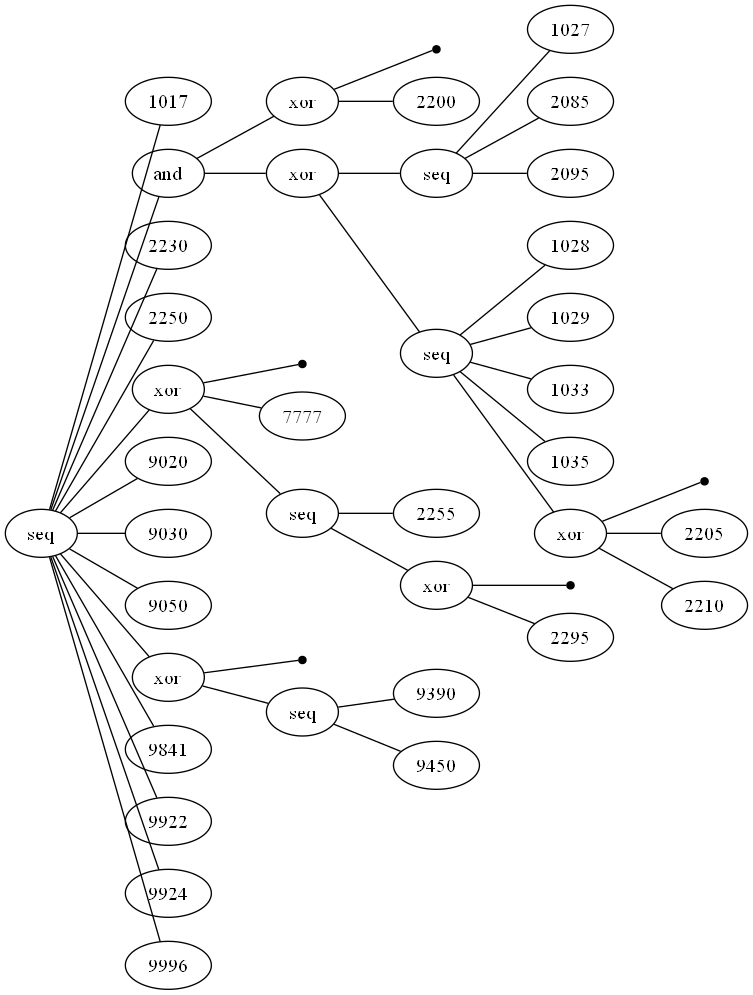

In [10]:
pm4py.view_process_tree(
    process_tree
)

## Convert to BPMN
Transform the process tree into a BPMN model for a different visual perspective.

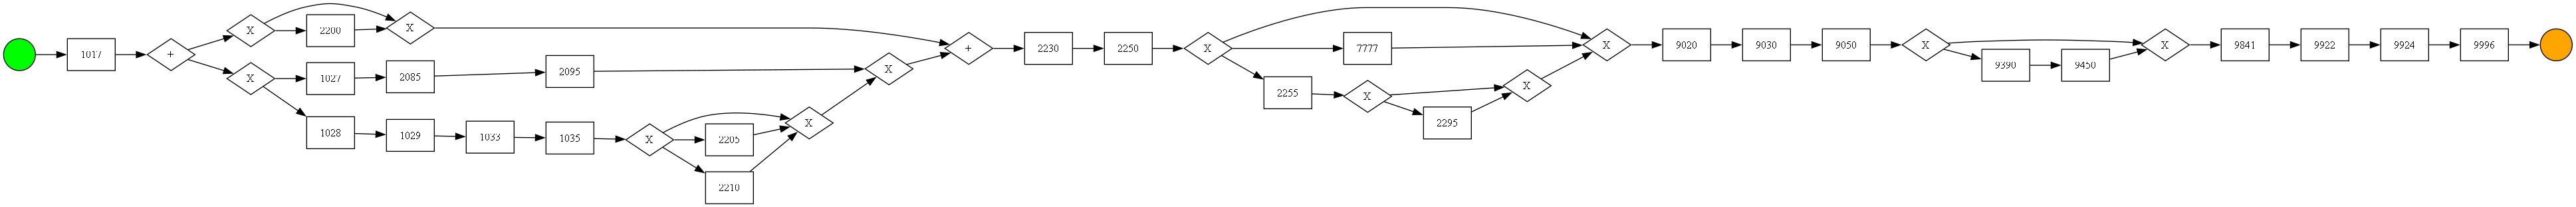

In [11]:
bpmn_model = pm4py.convert_to_bpmn(
    process_tree
)

pm4py.view_bpmn(
    bpmn_model
)

## Discover BPMN Model

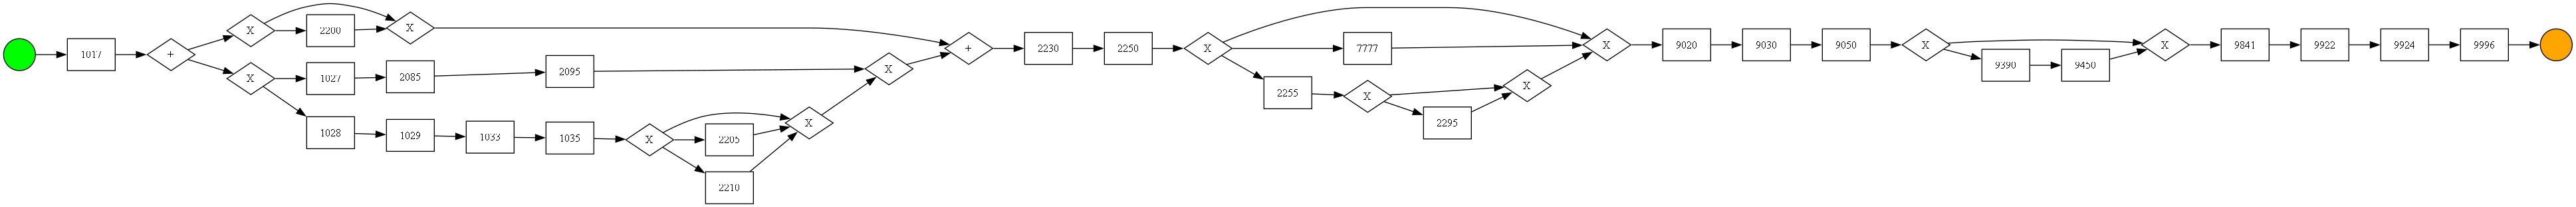

In [12]:
process_model = pm4py.discover_bpmn_inductive(
    event_log
)

pm4py.view_bpmn(
    process_model
)